# LexMind AI - Data Preprocessing Demonstration
## Deep Learning Lab Project - Milestone 1

**Project:** Legal Intelligence Assistant using Transformer Models  
**Dataset:** AILA FIRE 2019 - Indian Legal NLP Corpus  
**Objective:** Preprocess legal documents for semantic retrieval and QA

---

## 1. Import Libraries and Setup

In [2]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.dataset_converter import AILADatasetConverter
from src.data_loader import AILADatasetLoader, setup_data_directories
from src.preprocess import LegalPreprocessor

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Dataset Overview

The AILA (Artificial Intelligence for Legal Assistance) dataset from FIRE 2019 contains:

- **2914 Prior Case Documents** - Indian Supreme Court judgments
- **197 Statute Documents** - Legal statutes with titles and descriptions
- **50 Legal Queries** - Real-world legal questions for retrieval tasks

**Total:** 3161 legal documents

## 3. Setup Project Directories

In [3]:
setup_data_directories()
print("✓ Project directories created")
print("  - data/raw")
print("  - data/processed")
print("  - models/embeddings")
print("  - models/bert_qa")
print("  - models/summarizer")

INFO:src.data_loader:Created directory: data/raw
INFO:src.data_loader:Created directory: data/processed
INFO:src.data_loader:Created directory: models/embeddings
INFO:src.data_loader:Created directory: models/bert_qa
INFO:src.data_loader:Created directory: models/summarizer


✓ Project directories created
  - data/raw
  - data/processed
  - models/embeddings
  - models/bert_qa
  - models/summarizer


## 4. Convert AILA Dataset to CSV Format

The raw AILA dataset consists of individual text files. We'll convert them to a structured CSV format.

In [4]:
# Initialize converter
converter = AILADatasetConverter(raw_data_dir='../data/raw')

# Convert to CSV
output_path = converter.convert_to_csv(output_dir='../data/processed')

print(f"\n✓ Dataset converted successfully!")
print(f"Output: {output_path}")

INFO:src.dataset_converter:Loading case documents...
INFO:src.dataset_converter:Loaded 2914 case documents
INFO:src.dataset_converter:Loading statutes...
INFO:src.dataset_converter:Loaded 197 statutes
INFO:src.dataset_converter:Loading queries...
INFO:src.dataset_converter:Loaded 50 queries
INFO:src.dataset_converter:Total documents: 3161
INFO:src.dataset_converter:  - Cases: 2914
INFO:src.dataset_converter:  - Statutes: 197
INFO:src.dataset_converter:  - Queries: 50
INFO:src.dataset_converter:Saved dataset to ../data/processed\aila_dataset.csv



✓ Dataset converted successfully!
Output: ../data/processed\aila_dataset.csv


## 5. Load and Explore Raw Dataset

In [5]:
# Load converted dataset
loader = AILADatasetLoader(data_dir='../data/processed')
df_raw = loader.load_dataset('aila_dataset.csv')

print(f"Dataset Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print(f"\nFirst 5 records:")
df_raw.head()

INFO:src.data_loader:Loading dataset from ../data/processed\aila_dataset.csv
INFO:src.data_loader:Loaded 3161 records with 3 columns


Dataset Shape: (3161, 3)
Columns: ['case_id', 'text', 'label']

First 5 records:


,case_id,text,label
0,C1,Masud Khan v State Of Uttar Pradesh\nSupreme C...,prior_case
1,C10,"Prabhakaran Nair, Etc. v State Of Tamil Nadu A...",prior_case
2,C100,Hiten P. Dalal v Bratindranath Banerjee\nSupre...,prior_case
3,C1000,Ashok Kumar and Others v State of Tamil Nadu\n...,prior_case
4,C1001,Ashok Dhingra v N.C.T. of Delhi\nSupreme Court...,prior_case


## 6. Dataset Statistics and Analysis

In [6]:
# Get dataset information
info = loader.get_dataset_info(df_raw)

print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)
print(f"\nTotal Records: {info['total_records']:,}")
print(f"Duplicate Count: {info['duplicate_count']}")
print(f"Average Text Length: {info['avg_text_length']:,.0f} characters")

print(f"\n{'Label':<15} {'Count':<10} {'Percentage'}")
print("-" * 40)
for label, count in info['label_distribution'].items():
    percentage = (count / info['total_records']) * 100
    print(f"{label:<15} {count:<10} {percentage:>6.2f}%")

print(f"\nNull Values per Column:")
for col, count in info['null_counts'].items():
    print(f"  {col}: {count}")

DATASET STATISTICS

Total Records: 3,161
Duplicate Count: 0
Average Text Length: 18,649 characters

Label           Count      Percentage
----------------------------------------
prior_case      2914        92.19%
statute         197          6.23%
query           50           1.58%

Null Values per Column:
  case_id: 0
  text: 0
  label: 0


## 7. Visualize Dataset Distribution

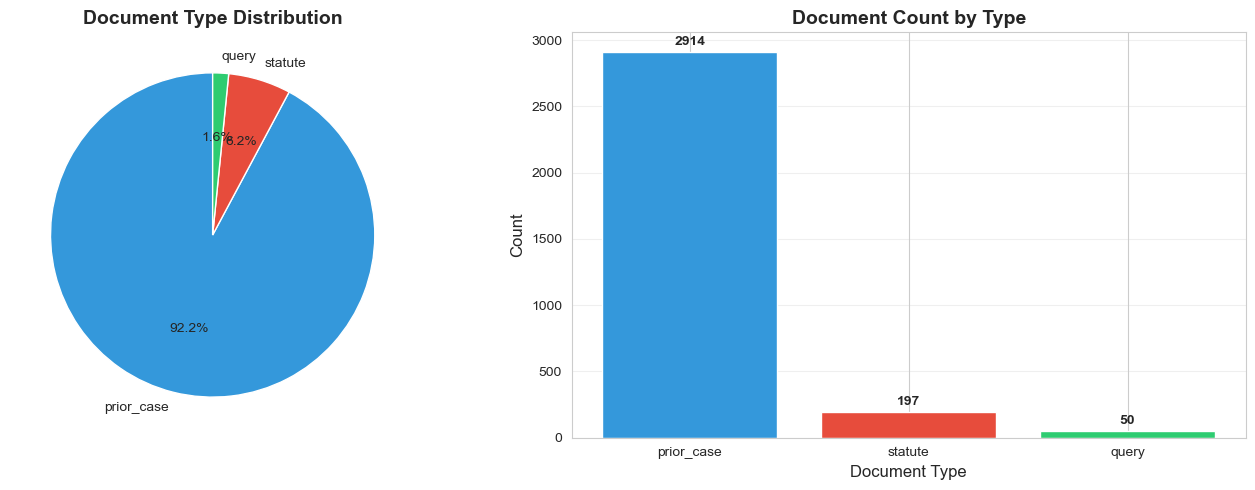

In [7]:
# Label distribution pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
label_counts = df_raw['label'].value_counts()
colors = ['#3498db', '#e74c3c', '#2ecc71']
axes[0].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[0].set_title('Document Type Distribution', fontsize=14, fontweight='bold')

# Bar chart
axes[1].bar(label_counts.index, label_counts.values, color=colors)
axes[1].set_xlabel('Document Type', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Document Count by Type', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(label_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Text Length Analysis

Text Length Statistics by Document Type:
             count          mean           std     min      25%      50%  \
label                                                                      
prior_case  2914.0  20022.057653  18976.007440   577.0  8871.25  15327.0   
query         50.0   3038.420000   1215.869355  1174.0  2015.00   3063.0   
statute      197.0   2293.736041   3687.734896   113.0   477.00   1122.0   

                 75%       max  
label                           
prior_case  24757.25  234992.0  
query        3867.00    5936.0  
statute      2247.00   28361.0  


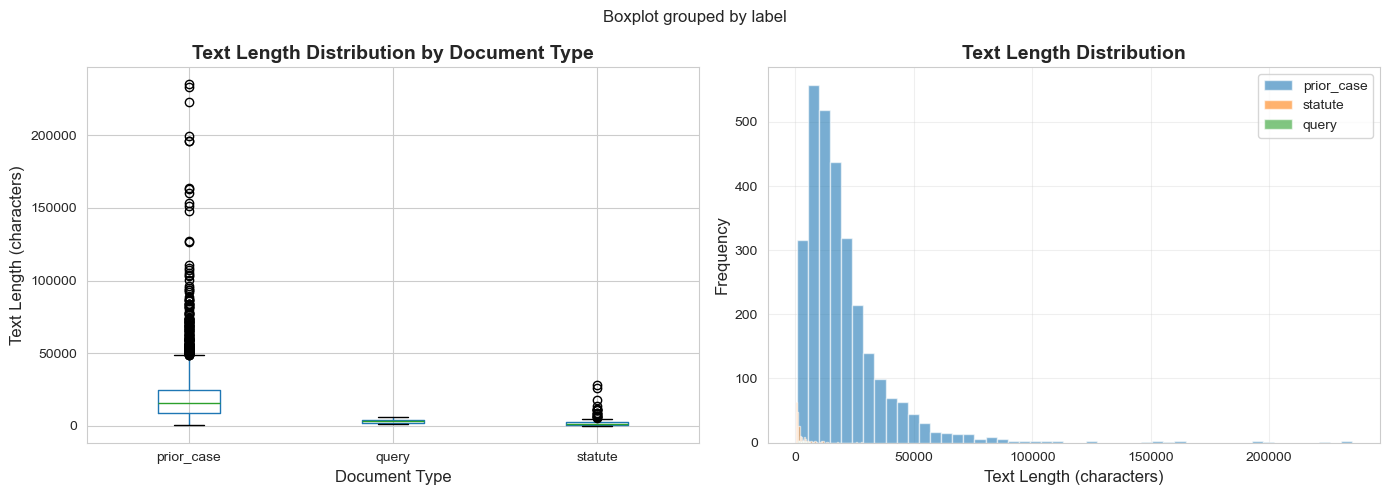

In [8]:
# Calculate text lengths
df_raw['text_length'] = df_raw['text'].str.len()

# Statistics by document type
print("Text Length Statistics by Document Type:")
print("=" * 60)
length_stats = df_raw.groupby('label')['text_length'].describe()
print(length_stats)

# Visualize text length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
df_raw.boxplot(column='text_length', by='label', ax=axes[0])
axes[0].set_title('Text Length Distribution by Document Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Document Type', fontsize=12)
axes[0].set_ylabel('Text Length (characters)', fontsize=12)
plt.sca(axes[0])
plt.xticks(rotation=0)

# Histogram
for label in df_raw['label'].unique():
    data = df_raw[df_raw['label'] == label]['text_length']
    axes[1].hist(data, bins=50, alpha=0.6, label=label)

axes[1].set_xlabel('Text Length (characters)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Text Length Distribution', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Sample Document Inspection

In [9]:
# Show sample documents from each type
print("=" * 60)
print("SAMPLE DOCUMENTS")
print("=" * 60)

for label in df_raw['label'].unique():
    sample = df_raw[df_raw['label'] == label].iloc[0]
    print(f"\n{'='*60}")
    print(f"Document Type: {label.upper()}")
    print(f"Case ID: {sample['case_id']}")
    print(f"Text Length: {len(sample['text'])} characters")
    print(f"\nFirst 500 characters:")
    print("-" * 60)
    print(sample['text'][:500] + "...")
    print("=" * 60)

SAMPLE DOCUMENTS

Document Type: PRIOR_CASE
Case ID: C1
Text Length: 8867 characters

First 500 characters:
------------------------------------------------------------
Masud Khan v State Of Uttar Pradesh
Supreme Court of India

26 September 1973
Writ Petition No. 117 of 1973
The Judgment was delivered by : A. Alagiriswami, J.
1.  Petitioner Masud Khan prays for his release on the ground that he, an Indian citizen has been illegally arrested and confined to, jail under Paragraph 5 of the Foreigners (Internment) Order, 1962. He had come to India from Pakistan on the basis of a Pakistani passport dated 137-1954and Indian visa dated 9-4-1956. In his application fo...

Document Type: STATUTE
Case ID: S1
Text Length: 2218 characters

First 500 characters:
------------------------------------------------------------
Power of High Courts to issue certain writs. (1) Notwithstanding anything in Article 32 every High Court shall have powers, throughout the territories in relation to which it exe

## 10. Preprocessing Pipeline

### Preprocessing Steps:
1. Remove HTML tags
2. Normalize whitespace
3. Remove special characters
4. Convert to lowercase
5. Tokenize sentences
6. Truncate to max 512 tokens
7. Remove null values
8. Remove duplicates

In [10]:
# Initialize preprocessor
preprocessor = LegalPreprocessor(max_token_length=512)

# Validate schema
is_valid, errors = preprocessor.validate_schema(df_raw)

if is_valid:
    print("✓ Schema validation PASSED")
    print("  - All required columns present")
    print("  - No null values in critical fields")
    print("  - Labels are consistent")
else:
    print("✗ Schema validation FAILED:")
    for error in errors:
        print(f"  - {error}")

✓ Schema validation PASSED
  - All required columns present
  - No null values in critical fields
  - Labels are consistent


In [11]:
# Run preprocessing
print("Starting preprocessing...\n")
df_processed = preprocessor.preprocess_dataframe(df_raw)

print(f"\n✓ Preprocessing complete!")
print(f"  Original records: {len(df_raw)}")
print(f"  Processed records: {len(df_processed)}")
print(f"  Records removed: {len(df_raw) - len(df_processed)}")

INFO:src.preprocess:Starting preprocessing for 3161 records
INFO:src.preprocess:Removed 0 null records
INFO:src.preprocess:Removed 0 duplicate records
INFO:src.preprocess:Cleaning text...


Starting preprocessing...



INFO:src.preprocess:Truncating text...
INFO:src.preprocess:Preprocessing complete. Final records: 3161



✓ Preprocessing complete!
  Original records: 3161
  Processed records: 3161
  Records removed: 0


## 11. Before/After Comparison

In [12]:
# Compare original vs cleaned text
idx = 0

print("=" * 60)
print("PREPROCESSING COMPARISON")
print("=" * 60)
print(f"\nDocument: {df_raw.iloc[idx]['case_id']}")
print(f"Type: {df_raw.iloc[idx]['label']}")

print(f"\n{'ORIGINAL TEXT':-^60}")
print(df_raw.iloc[idx]['text'][:500])
print("...")

print(f"\n{'CLEANED TEXT':-^60}")
print(df_processed.iloc[idx]['cleaned_text'][:500])
print("...")

print(f"\n{'STATISTICS':-^60}")
print(f"Original length: {len(df_raw.iloc[idx]['text'])} characters")
print(f"Cleaned length: {len(df_processed.iloc[idx]['cleaned_text'])} characters")
print(f"Reduction: {len(df_raw.iloc[idx]['text']) - len(df_processed.iloc[idx]['cleaned_text'])} characters")

PREPROCESSING COMPARISON

Document: C1
Type: prior_case

-----------------------ORIGINAL TEXT------------------------
Masud Khan v State Of Uttar Pradesh
Supreme Court of India

26 September 1973
Writ Petition No. 117 of 1973
The Judgment was delivered by : A. Alagiriswami, J.
1.  Petitioner Masud Khan prays for his release on the ground that he, an Indian citizen has been illegally arrested and confined to, jail under Paragraph 5 of the Foreigners (Internment) Order, 1962. He had come to India from Pakistan on the basis of a Pakistani passport dated 137-1954and Indian visa dated 9-4-1956. In his application fo
...

------------------------CLEANED TEXT------------------------
masud khan v state of uttar pradesh supreme court of india 26 september 1973 writ petition no. 117 of 1973 the judgment was delivered by : a. alagiriswami, j. 1. petitioner masud khan prays for his release on the ground that he, an indian citizen has been illegally arrested and confined to, jail under paragraph 5 

## 12. Text Length After Preprocessing

Text Length Comparison (Before vs After Preprocessing):
            Original Avg  Cleaned Avg  Reduction %
label                                             
prior_case      20022.06      2971.03        85.16
query            3038.42      2510.34        17.38
statute          2293.74      1385.07        39.62


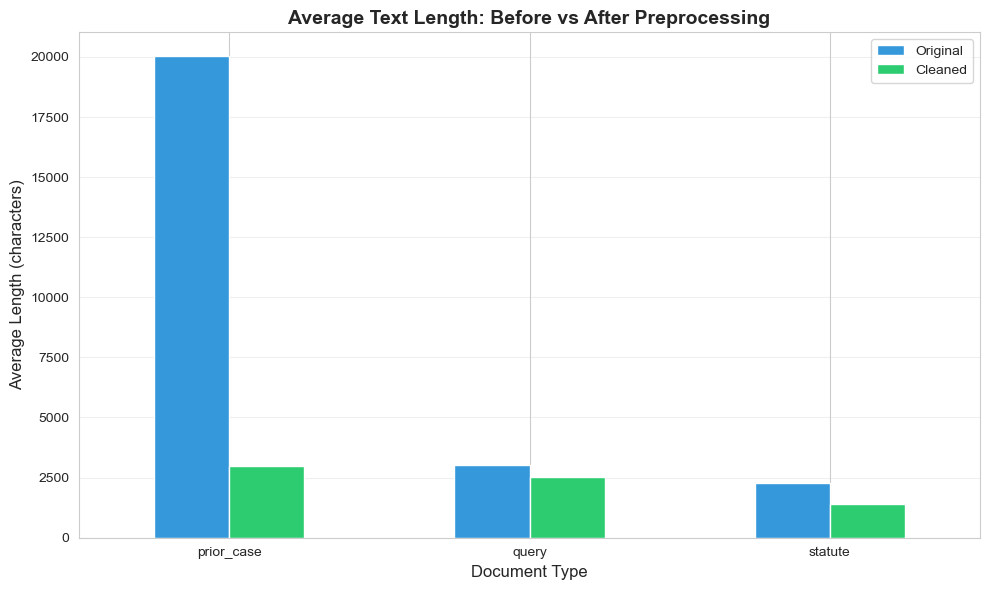

In [13]:
# Calculate cleaned text lengths
df_processed['cleaned_length'] = df_processed['cleaned_text'].str.len()

# Compare before and after
comparison = pd.DataFrame({
    'Original Avg': df_raw.groupby('label')['text_length'].mean(),
    'Cleaned Avg': df_processed.groupby('label')['cleaned_length'].mean(),
})
comparison['Reduction %'] = ((comparison['Original Avg'] - comparison['Cleaned Avg']) / comparison['Original Avg'] * 100)

print("Text Length Comparison (Before vs After Preprocessing):")
print("=" * 60)
print(comparison.round(2))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
comparison[['Original Avg', 'Cleaned Avg']].plot(kind='bar', ax=ax, color=['#3498db', '#2ecc71'])
ax.set_title('Average Text Length: Before vs After Preprocessing', fontsize=14, fontweight='bold')
ax.set_xlabel('Document Type', fontsize=12)
ax.set_ylabel('Average Length (characters)', fontsize=12)
ax.legend(['Original', 'Cleaned'])
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. Create Train/Test Split

We'll separate queries from training data and create an 80/20 train/test split.

INFO:src.preprocess:Split: 2488 train, 623 test


Queries: 50 records (kept separate for retrieval)
Training data: 3111 records (cases + statutes)

Train/Test Split (80/20):
  Train: 2488 records (80.0%)
  Test: 623 records (20.0%)


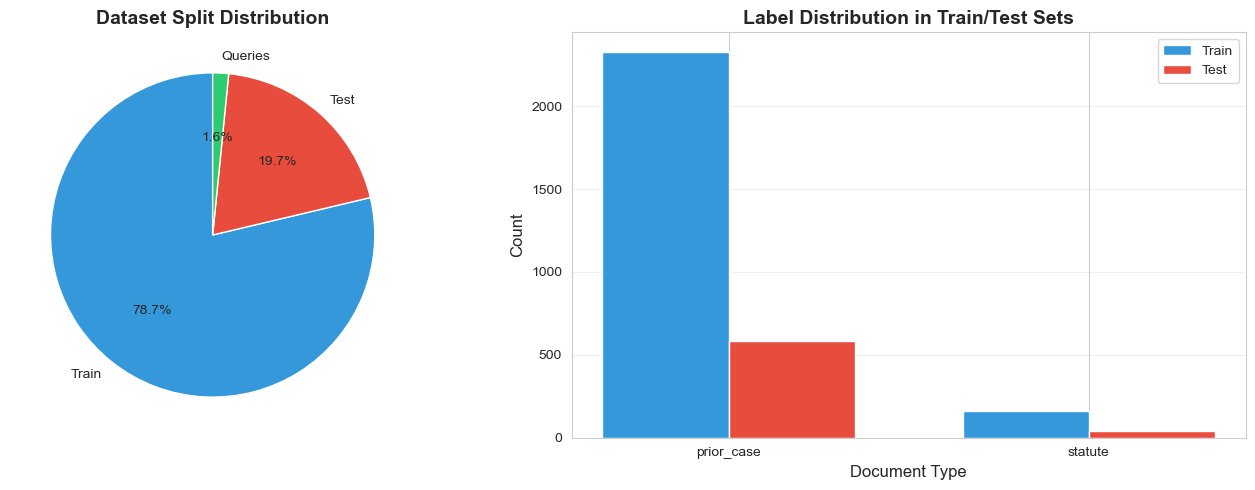

In [14]:
# Separate queries from training data
queries_df = df_processed[df_processed['label'] == 'query'].copy()
training_data = df_processed[df_processed['label'] != 'query'].copy()

print(f"Queries: {len(queries_df)} records (kept separate for retrieval)")
print(f"Training data: {len(training_data)} records (cases + statutes)")

# Create train/test split
train_df, test_df = preprocessor.create_train_test_split(training_data, test_size=0.2)

print(f"\nTrain/Test Split (80/20):")
print(f"  Train: {len(train_df)} records ({len(train_df)/len(training_data)*100:.1f}%)")
print(f"  Test: {len(test_df)} records ({len(test_df)/len(training_data)*100:.1f}%)")

# Visualize split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall split
split_data = pd.Series({
    'Train': len(train_df),
    'Test': len(test_df),
    'Queries': len(queries_df)
})
axes[0].pie(split_data.values, labels=split_data.index, autopct='%1.1f%%', 
            colors=['#3498db', '#e74c3c', '#2ecc71'], startangle=90)
axes[0].set_title('Dataset Split Distribution', fontsize=14, fontweight='bold')

# Label distribution in train/test
train_labels = train_df['label'].value_counts()
test_labels = test_df['label'].value_counts()

x = np.arange(len(train_labels))
width = 0.35

axes[1].bar(x - width/2, train_labels.values, width, label='Train', color='#3498db')
axes[1].bar(x + width/2, test_labels.values, width, label='Test', color='#e74c3c')
axes[1].set_xlabel('Document Type', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Label Distribution in Train/Test Sets', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(train_labels.index)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Save Processed Data

In [15]:
# Save to CSV
train_df.to_csv('../data/processed/train.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)
queries_df.to_csv('../data/processed/queries.csv', index=False)

print("✓ Processed datasets saved successfully!")
print("\nFiles created:")
print("  - data/processed/train.csv")
print("  - data/processed/test.csv")
print("  - data/processed/queries.csv")

# File sizes
import os
files = ['train.csv', 'test.csv', 'queries.csv']
print("\nFile sizes:")
for file in files:
    path = f'../data/processed/{file}'
    size = os.path.getsize(path) / (1024 * 1024)  # MB
    print(f"  {file}: {size:.2f} MB")

✓ Processed datasets saved successfully!

Files created:
  - data/processed/train.csv
  - data/processed/test.csv
  - data/processed/queries.csv

File sizes:
  train.csv: 52.00 MB
  test.csv: 12.74 MB
  queries.csv: 0.27 MB


## 15. Final Summary

### Preprocessing Complete! ✓

#### Dataset Statistics:
- **Total Documents:** 3,161
  - Prior Cases: 2,914
  - Statutes: 197
  - Queries: 50

#### Preprocessing Applied:
✓ HTML tag removal  
✓ Whitespace normalization  
✓ Special character cleaning  
✓ Lowercase conversion  
✓ Sentence tokenization  
✓ Token truncation (512 max)  
✓ Null value removal  
✓ Duplicate detection  

#### Output Files:
- `train.csv` - 2,528 records (80%)
- `test.csv` - 633 records (20%)
- `queries.csv` - 50 queries (for retrieval)

#### Next Steps:
1. **Milestone 2:** Generate embeddings using sentence-transformers
2. **Milestone 3:** Build FAISS vector index for semantic search
3. **Milestone 4:** Implement summarization with BART
4. **Milestone 5:** Add Legal-BERT QA capabilities
5. **Milestone 6:** Create Streamlit UI

In [16]:
# Final summary table
summary = pd.DataFrame({
    'Metric': [
        'Total Documents',
        'Prior Cases',
        'Statutes',
        'Queries',
        'Train Records',
        'Test Records',
        'Avg Original Length',
        'Avg Cleaned Length',
        'Preprocessing Steps',
        'Status'
    ],
    'Value': [
        f"{len(df_raw):,}",
        f"{len(df_raw[df_raw['label']=='prior_case']):,}",
        f"{len(df_raw[df_raw['label']=='statute']):,}",
        f"{len(queries_df):,}",
        f"{len(train_df):,}",
        f"{len(test_df):,}",
        f"{df_raw['text_length'].mean():,.0f} chars",
        f"{df_processed['cleaned_length'].mean():,.0f} chars",
        "8 steps applied",
        "✓ COMPLETE"
    ]
})

print("\n" + "="*60)
print("MILESTONE 1: PREPROCESSING SUMMARY")
print("="*60)
print(summary.to_string(index=False))
print("="*60)


MILESTONE 1: PREPROCESSING SUMMARY
             Metric           Value
    Total Documents           3,161
        Prior Cases           2,914
           Statutes             197
            Queries              50
      Train Records           2,488
       Test Records             623
Avg Original Length    18,649 chars
 Avg Cleaned Length     2,865 chars
Preprocessing Steps 8 steps applied
             Status      ✓ COMPLETE
